# Metacommunity buffering

In [1]:
import numpy as np
import pyrepseq as prs

import matplotlib.pyplot as plt

import repertoire_simulator.lib as lib


plt.style.use("../../project_style.mplstyle")
%config InlineBackend.figure_format = 'retina'

DATA_PATH = "../../data/"

/Users/james/Documents/Projects/repertoire_sims_2026/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
Ns = np.linspace(1, 20, 10).astype(int)
results_for_patches = {}
for N in Ns:
    records = np.load(DATA_PATH + f"how_to_maintain_diversity/metacommunity_buffering/patches_{N}.npz", allow_pickle=True)
    t = records['t']
    c_t = records['c']
    Seff_global = np.zeros(len(t))
    Seff_local = np.zeros(len(t))
    
    for i, time in enumerate(t):
        Seff_global[i] = lib.get_global_simpsons_diversity(c_t[i])
        Seff_local[i] = lib.get_average_simpsons_diversity(c_t[i])
    
    results_for_patches[N] = {'t':t, 'Seff_global':Seff_global, 'Seff_local':Seff_local}

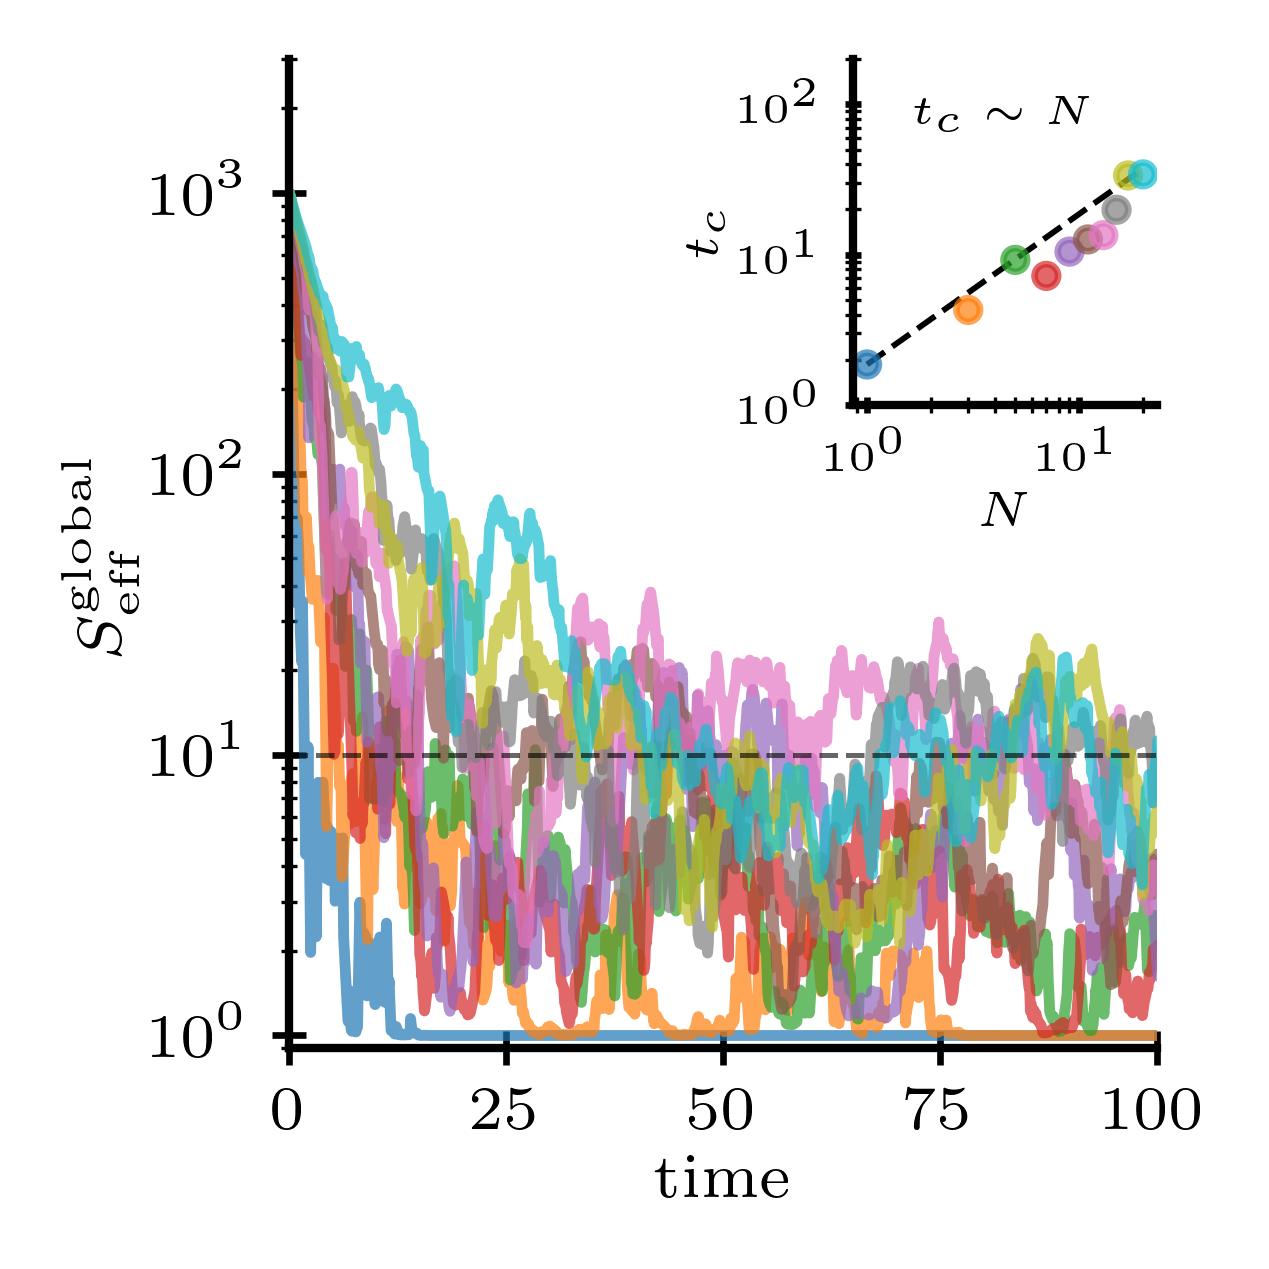

In [3]:
fig, ax = plt.subplots(figsize=(2, 2), layout='constrained')

t_cs = np.full(len(Ns), np.nan)
colors = []
for i, N in enumerate(Ns):
    t = results_for_patches[N]['t']
    Seff_global = results_for_patches[N]['Seff_global']

    line, = ax.plot(t, Seff_global, alpha=0.7)
    colors.append(line.get_color())

    below = np.where(Seff_global <= 10)[0]
    if len(below) > 0:
        t_cs[i] = t[below[0]]

ax.axhline(10, color='k', lw=0.6, ls='--', alpha=0.6)

ax.set_yscale('log')
ax.set_xlim(0, 100)
ax.set_ylim(0.9, 3e3)
ax.set_xlabel(r'time')
ax.set_ylabel(r'$S_{\mathrm{eff}}^{\mathrm{global}}$')

inset = ax.inset_axes([0.65, 0.65, 0.35, 0.35])

mask = np.isfinite(t_cs)
inset.scatter(Ns[mask], t_cs[mask], s=8, c=np.asarray(colors)[mask], alpha=0.7)
inset.plot(Ns, Ns*t_cs[0], linestyle='--', c='black', lw=0.7, zorder=-2)
inset.text(0.2, 0.9, r'$t_c \sim N$', transform=inset.transAxes, fontsize=5, ha='left',va='top')
inset.set_xscale('log')
inset.set_yscale('log')
inset.set_ylim([1, 200])

inset.set_xlabel(r'$N$', fontsize=6)
inset.set_ylabel(r'$t_c$', fontsize=6)
inset.tick_params(axis='both', labelsize=5, length=2)

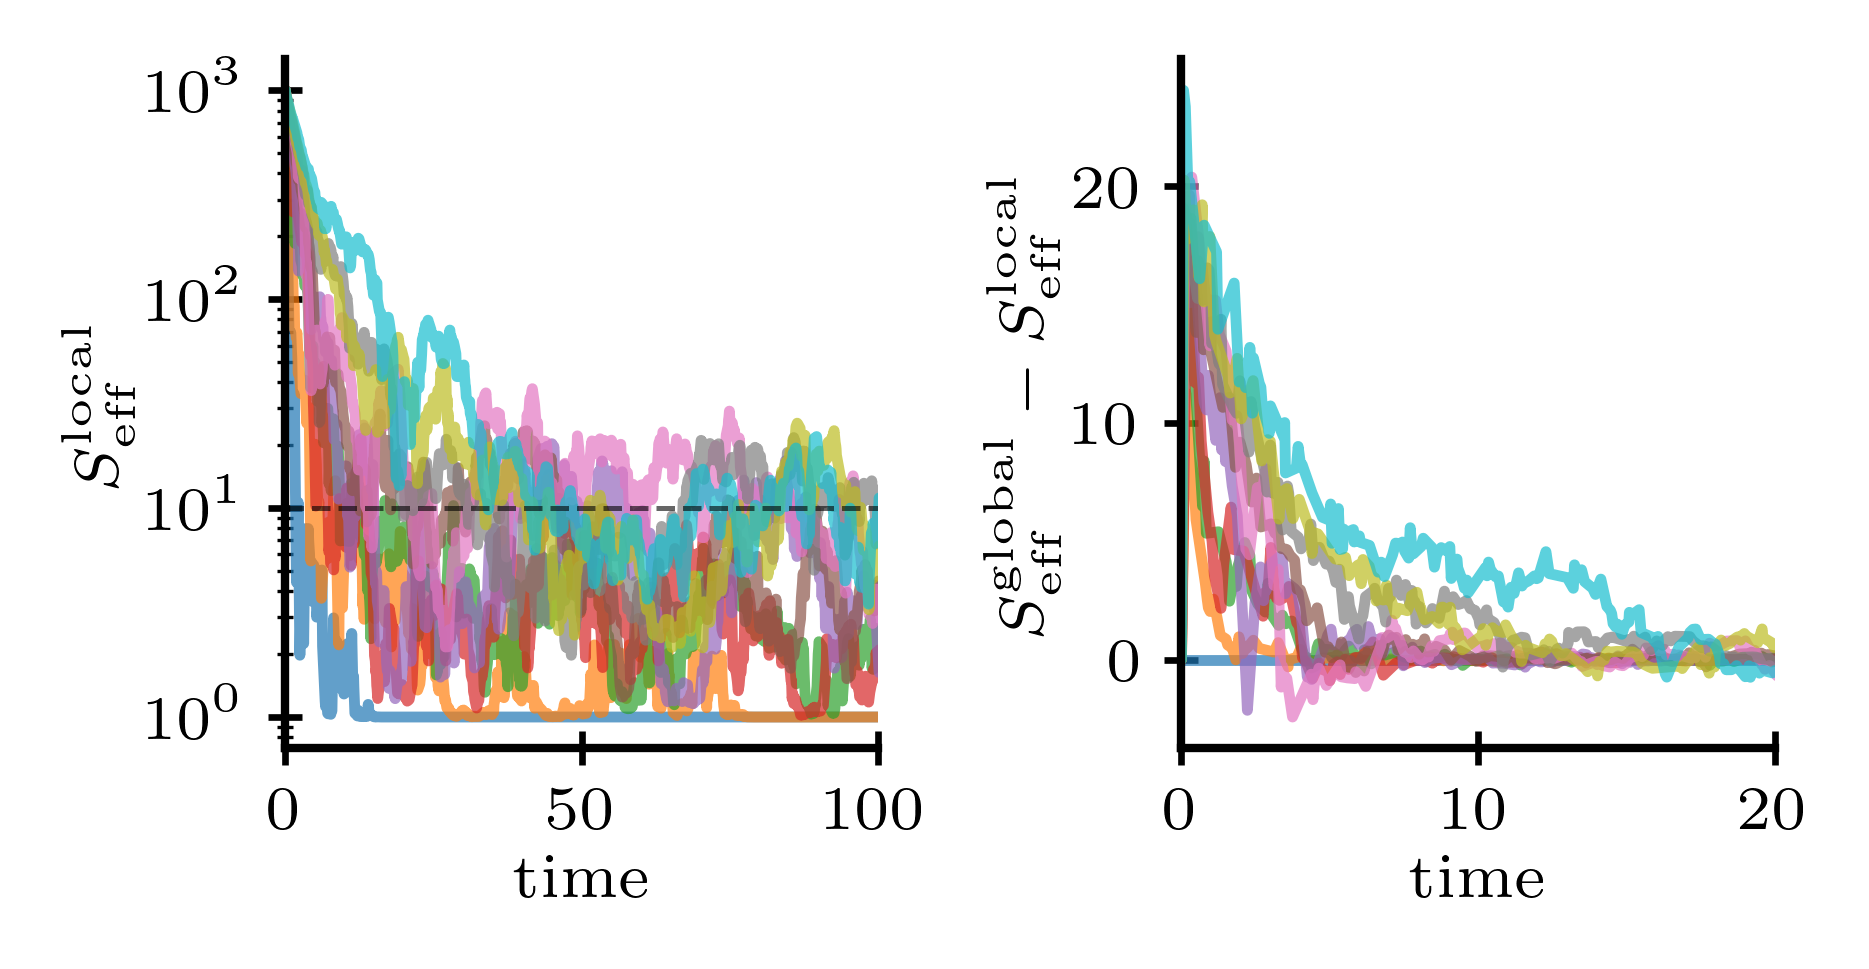

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(3, 1.5), layout='constrained')
for N in Ns:    
    ax[0].plot(results_for_patches[N]['t'], results_for_patches[N]['Seff_local'], alpha=0.7)
    ax[1].plot(results_for_patches[N]['t'], results_for_patches[N]['Seff_global'] - results_for_patches[N]['Seff_local'], alpha=0.7)
        
ax[0].axhline(10, color='k', lw=0.6, ls='--', alpha=0.6)
ax[0].set_xlim(0, 100)
ax[0].set_yscale('log')
ax[0].set_xlabel(r'time')
ax[0].set_ylabel(r'$S^{\mathrm{local}}_{\mathrm{eff}}$')

ax[1].set_xlim(0, 20)
ax[1].set_xlabel(r'time')
ax[1].set_ylabel(r'$S^{\mathrm{global}}_{\mathrm{eff}} - S^{\mathrm{local}}_{\mathrm{eff}}$');